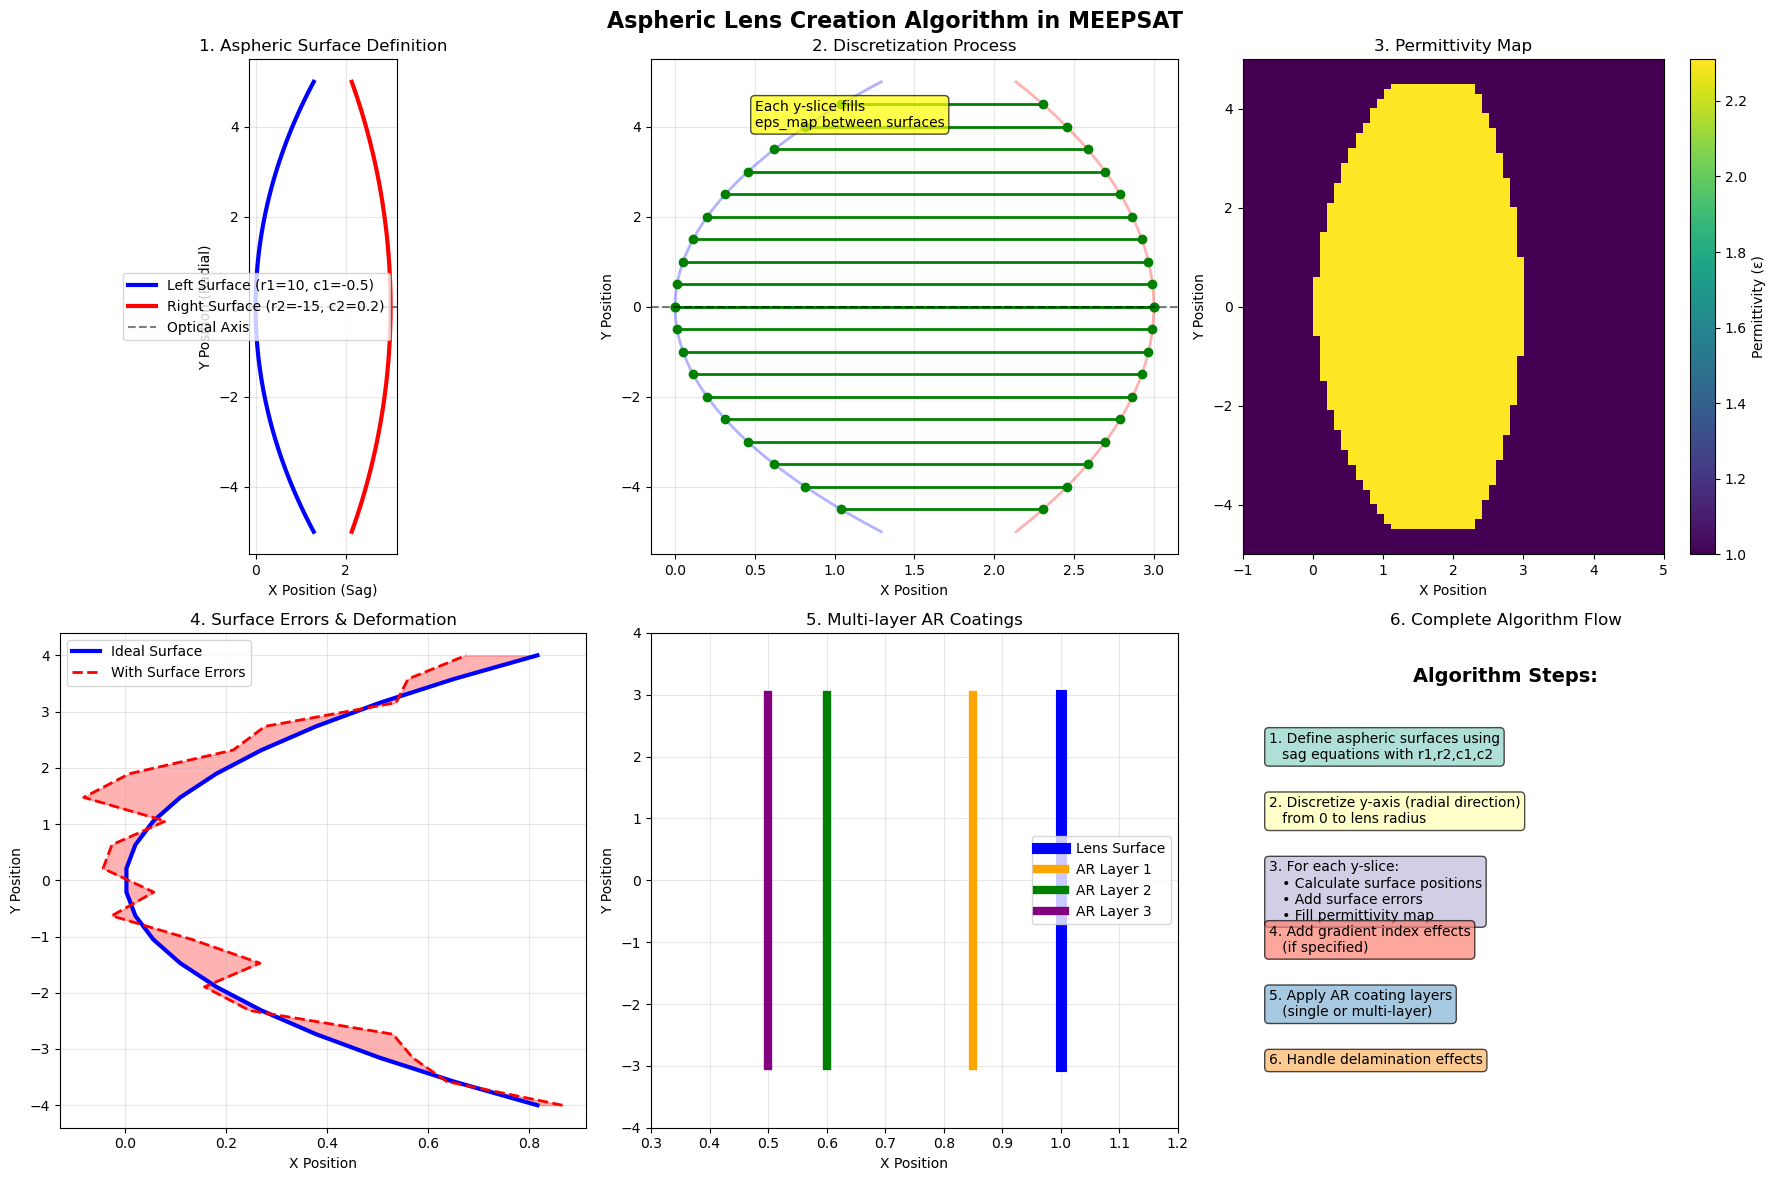

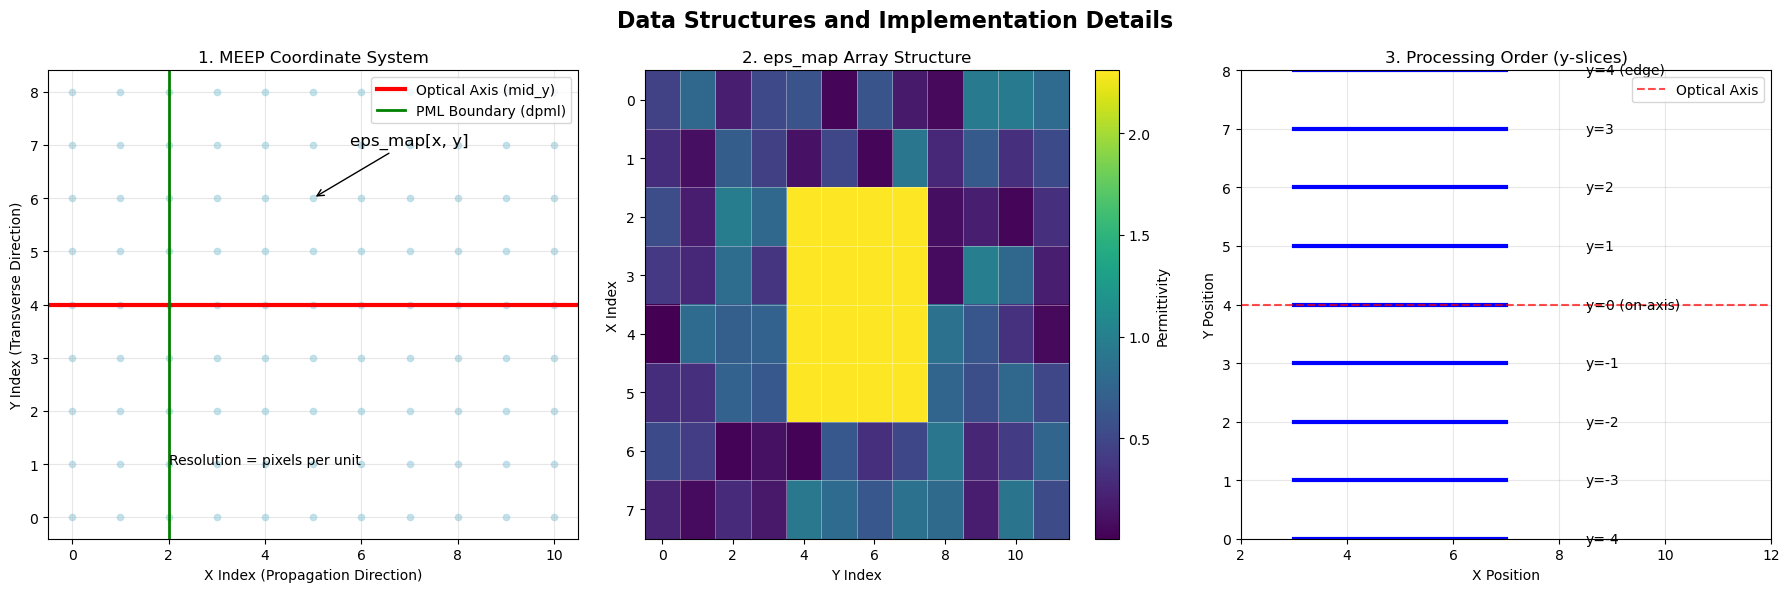

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Polygon
import matplotlib.patches as patches

# Create a comprehensive visualization of the lens creation algorithm
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Aspheric Lens Creation Algorithm in MeepSAT', fontsize=16, fontweight='bold')

# 1. Aspheric Surface Definition
ax1 = axes[0, 0]
y = np.linspace(-5, 5, 100)
r1, c1 = 10, -0.5  # Example parameters
r2, c2 = -15, 0.2

# Left surface (convex)
x_left = (y**2/r1) / (1 + np.sqrt(1 - (1 + c1)*y**2/r1**2))
# Right surface (concave)  
x_right = (y**2/r2) / (1 + np.sqrt(1 - (1 + c2)*y**2/r2**2)) + 3

ax1.plot(x_left, y, 'b-', linewidth=3, label='Left Surface (r1=10, c1=-0.5)')
ax1.plot(x_right, y, 'r-', linewidth=3, label='Right Surface (r2=-15, c2=0.2)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Optical Axis')
ax1.set_xlabel('X Position (Sag)')
ax1.set_ylabel('Y Position (Radial)')
ax1.set_title('1. Aspheric Surface Definition')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# 2. Discretization Process
ax2 = axes[0, 1]
# Show how the continuous surface is discretized
y_discrete = np.arange(0, 5, 0.5)
x_left_discrete = (y_discrete**2/r1) / (1 + np.sqrt(1 - (1 + c1)*y_discrete**2/r1**2))
x_right_discrete = (y_discrete**2/r2) / (1 + np.sqrt(1 - (1 + c2)*y_discrete**2/r2**2)) + 3

# Plot continuous curves
ax2.plot(x_left, y, 'b-', alpha=0.3, linewidth=2)
ax2.plot(x_right, y, 'r-', alpha=0.3, linewidth=2)

# Plot discrete points and horizontal lines
for i, (xl, xr, y_val) in enumerate(zip(x_left_discrete, x_right_discrete, y_discrete)):
    ax2.plot([xl, xr], [y_val, y_val], 'go-', linewidth=2, markersize=6)
    ax2.plot([xl, xr], [-y_val, -y_val], 'go-', linewidth=2, markersize=6)
    
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
ax2.set_title('2. Discretization Process')
ax2.text(0.5, 4, 'Each y-slice fills\neps_map between surfaces', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
ax2.grid(True, alpha=0.3)

# 3. Permittivity Map Creation
ax3 = axes[0, 2]
# Create a simple permittivity map representation
x_grid = np.linspace(-1, 5, 60)
y_grid = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
eps_map = np.ones_like(X)  # Background permittivity = 1

# Fill lens region
for i, y_val in enumerate(y_grid):
    if abs(y_val) <= 4.5:  # Within lens diameter
        y_norm = y_val
        x_l = (y_norm**2/r1) / (1 + np.sqrt(1 - (1 + c1)*y_norm**2/r1**2))
        x_r = (y_norm**2/r2) / (1 + np.sqrt(1 - (1 + c2)*y_norm**2/r2**2)) + 3
        
        mask = (X[i, :] >= x_l) & (X[i, :] <= x_r)
        eps_map[i, mask] = 2.31  # n=1.52 squared

im = ax3.imshow(eps_map, extent=[-1, 5, -5, 5], aspect='auto', cmap='viridis')
ax3.set_xlabel('X Position')
ax3.set_ylabel('Y Position')
ax3.set_title('3. Permittivity Map')
plt.colorbar(im, ax=ax3, label='Permittivity (ε)')

# 4. Surface Errors and Deformation
ax4 = axes[1, 0]
# Show how surface errors affect the lens
y_err = np.linspace(-4, 4, 20)
np.random.seed(42)  # For reproducible results
surface_errors = np.random.normal(0, 0.1, len(y_err))

x_left_ideal = (y_err**2/r1) / (1 + np.sqrt(1 - (1 + c1)*y_err**2/r1**2))
x_left_with_errors = x_left_ideal + surface_errors

ax4.plot(x_left_ideal, y_err, 'b-', linewidth=3, label='Ideal Surface')
ax4.plot(x_left_with_errors, y_err, 'r--', linewidth=2, label='With Surface Errors')
ax4.fill_betweenx(y_err, x_left_ideal, x_left_with_errors, alpha=0.3, color='red')
ax4.set_xlabel('X Position')
ax4.set_ylabel('Y Position')
ax4.set_title('4. Surface Errors & Deformation')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. AR Coating Layers
ax5 = axes[1, 1]
# Show multi-layer AR coating structure
lens_surface = np.array([[1, -3], [1, 3]])
ax5.plot(lens_surface[:, 0], lens_surface[:, 1], 'b-', linewidth=8, label='Lens Surface')

# AR layers
colors = ['orange', 'green', 'purple']
layer_thicks = [0.15, 0.25, 0.1]
x_pos = 1

for i, (thick, color) in enumerate(zip(layer_thicks, colors)):
    x_pos -= thick
    layer_surface = np.array([[x_pos, -3], [x_pos, 3]])
    ax5.plot(layer_surface[:, 0], layer_surface[:, 1], color=color, 
             linewidth=6, label=f'AR Layer {i+1}')

ax5.set_xlim(0.3, 1.2)
ax5.set_ylim(-4, 4)
ax5.set_xlabel('X Position')
ax5.set_ylabel('Y Position')
ax5.set_title('5. Multi-layer AR Coatings')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Complete Algorithm Flow
ax6 = axes[1, 2]
ax6.text(0.5, 0.9, 'Algorithm Steps:', ha='center', fontsize=14, fontweight='bold', transform=ax6.transAxes)

steps = [
    '1. Define aspheric surfaces using\n   sag equations with r1,r2,c1,c2',
    '2. Discretize y-axis (radial direction)\n   from 0 to lens radius',
    '3. For each y-slice:\n   • Calculate surface positions\n   • Add surface errors\n   • Fill permittivity map',
    '4. Add gradient index effects\n   (if specified)',
    '5. Apply AR coating layers\n   (single or multi-layer)',
    '6. Handle delamination effects'
]

for i, step in enumerate(steps):
    ax6.text(0.05, 0.8 - i*0.13, step, ha='left', va='top', fontsize=10, 
             transform=ax6.transAxes, bbox=dict(boxstyle="round,pad=0.3", 
             facecolor=plt.cm.Set3(i), alpha=0.7))

ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.set_title('6. Complete Algorithm Flow')

plt.tight_layout()
plt.show()

# Create a second figure showing the data structures
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Data Structures and Implementation Details', fontsize=16, fontweight='bold')

# 1. Coordinate System
ax1 = axes2[0]
# Show the MEEP coordinate system
x_range = np.linspace(0, 10, 11)
y_range = np.linspace(0, 8, 9)
X_coord, Y_coord = np.meshgrid(x_range, y_range)

ax1.scatter(X_coord, Y_coord, c='lightblue', s=20, alpha=0.7)
ax1.axhline(y=4, color='red', linewidth=3, label='Optical Axis (mid_y)')
ax1.axvline(x=2, color='green', linewidth=2, label='PML Boundary (dpml)')

# Add annotations
ax1.annotate('eps_map[x, y]', xy=(5, 6), xytext=(7, 7),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=12, ha='center')
ax1.annotate('Resolution = pixels per unit', xy=(2, 1), fontsize=10)

ax1.set_xlabel('X Index (Propagation Direction)')
ax1.set_ylabel('Y Index (Transverse Direction)')
ax1.set_title('1. MEEP Coordinate System')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Memory Layout
ax2 = axes2[1]
# Show how the permittivity map is structured
eps_example = np.random.rand(8, 12)
eps_example[2:6, 4:8] = 2.31  # Lens region

im2 = ax2.imshow(eps_example, cmap='viridis', aspect='auto')
ax2.set_xlabel('Y Index')
ax2.set_ylabel('X Index')
ax2.set_title('2. eps_map Array Structure')

# Add grid lines to show pixels
for i in range(eps_example.shape[0]+1):
    ax2.axhline(i-0.5, color='white', linewidth=0.5, alpha=0.5)
for j in range(eps_example.shape[1]+1):
    ax2.axvline(j-0.5, color='white', linewidth=0.5, alpha=0.5)

plt.colorbar(im2, ax=ax2, label='Permittivity')

# 3. Processing Order
ax3 = axes2[2]
# Show the order of processing
y_positions = [0, 1, 2, 3, 4]
process_order = ['y=0 (on-axis)', 'y=1', 'y=2', 'y=3', 'y=4 (edge)']

for i, (y_pos, label) in enumerate(zip(y_positions, process_order)):
    # Draw lens cross-section for each y-slice
    x_left_pos = 3
    x_right_pos = 7
    
    # Show symmetry
    ax3.plot([x_left_pos, x_right_pos], [4+y_pos, 4+y_pos], 'b-', linewidth=3)
    if y_pos > 0:  # Show symmetric part
        ax3.plot([x_left_pos, x_right_pos], [4-y_pos, 4-y_pos], 'b-', linewidth=3)
    
    # Add labels
    ax3.text(8.5, 4+y_pos, label, va='center', fontsize=10)
    if y_pos > 0:
        ax3.text(8.5, 4-y_pos, f'y=-{y_pos}', va='center', fontsize=10)

ax3.axhline(y=4, color='red', linestyle='--', alpha=0.7, label='Optical Axis')
ax3.set_xlim(2, 12)
ax3.set_ylim(0, 8)
ax3.set_xlabel('X Position')
ax3.set_ylabel('Y Position')
ax3.set_title('3. Processing Order (y-slices)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

AsphericLens Feature Visualization
Creating comprehensive lens features overview...


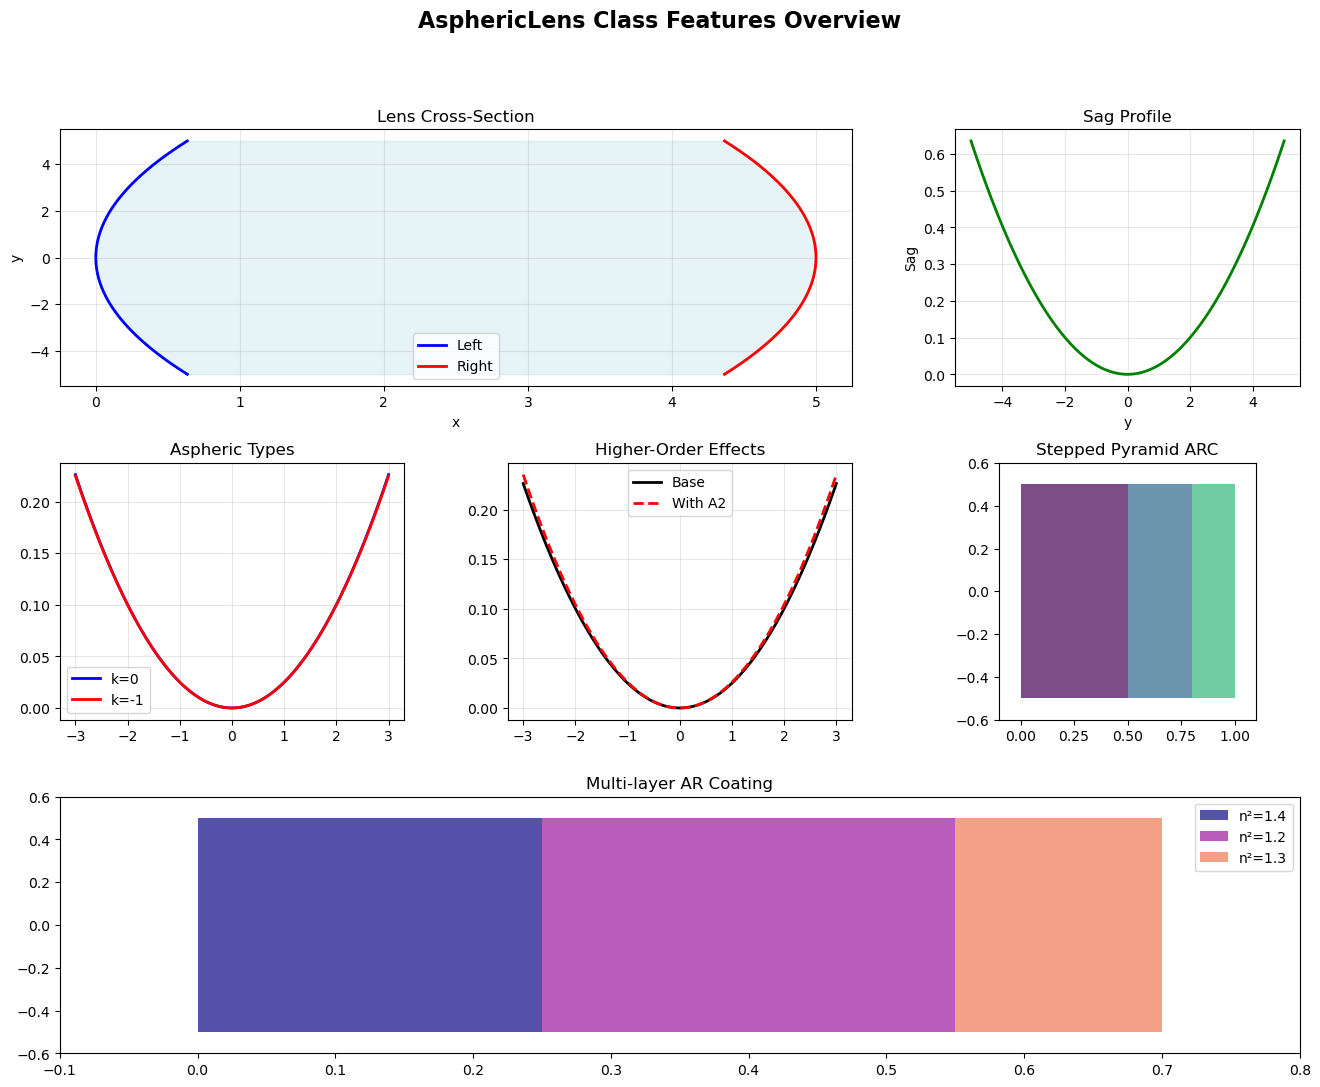


Creating individual feature plots...
1. Plotting lens sag profiles...


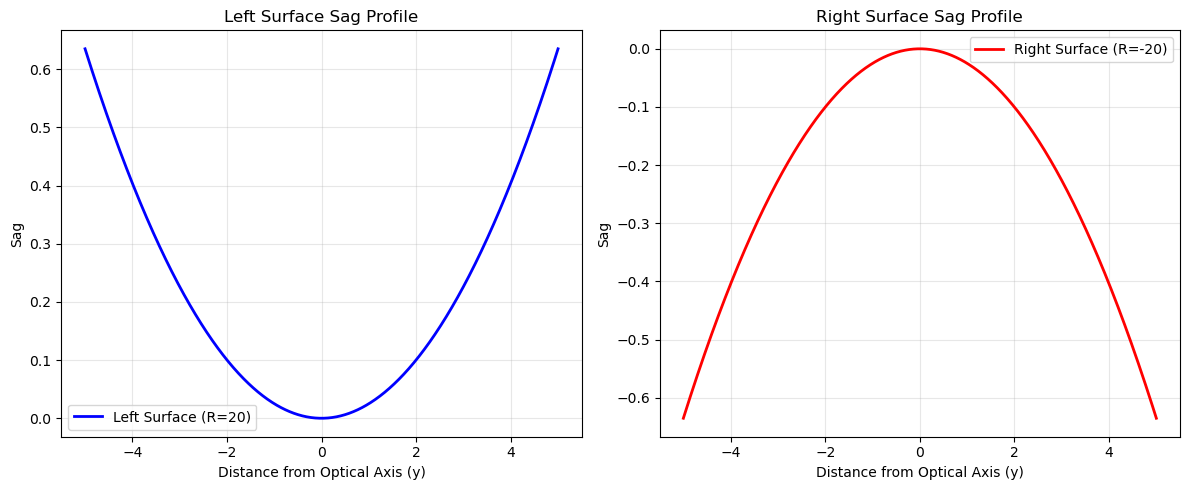

2. Plotting lens cross-section...


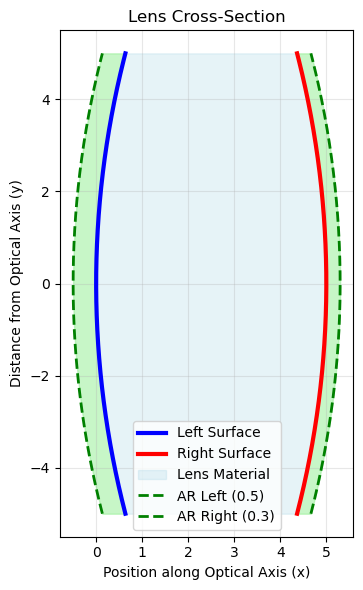

3. Plotting aspheric surface comparison...


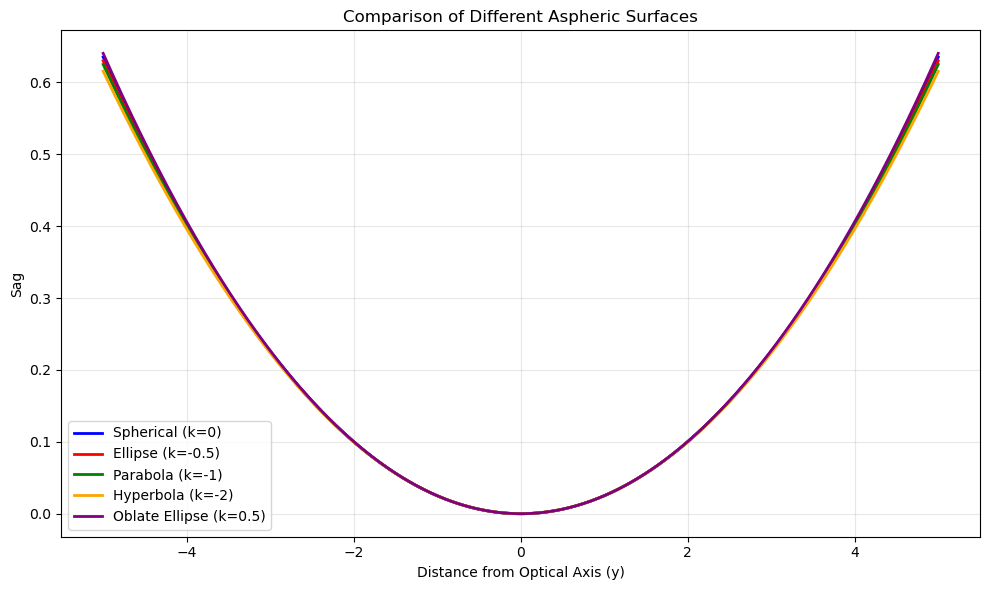

4. Plotting higher-order coefficient effects...


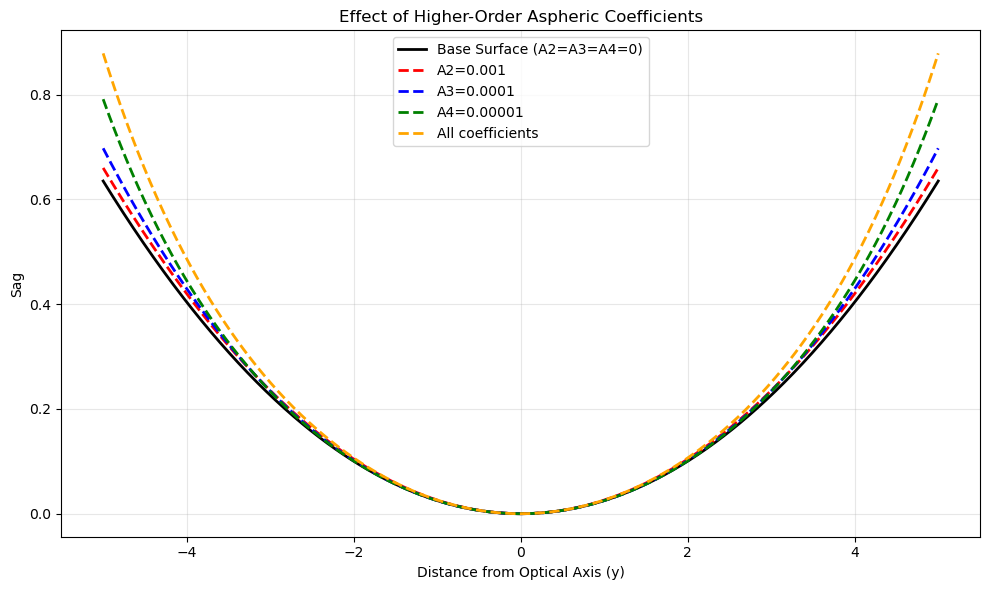

5. Plotting lens types comparison...


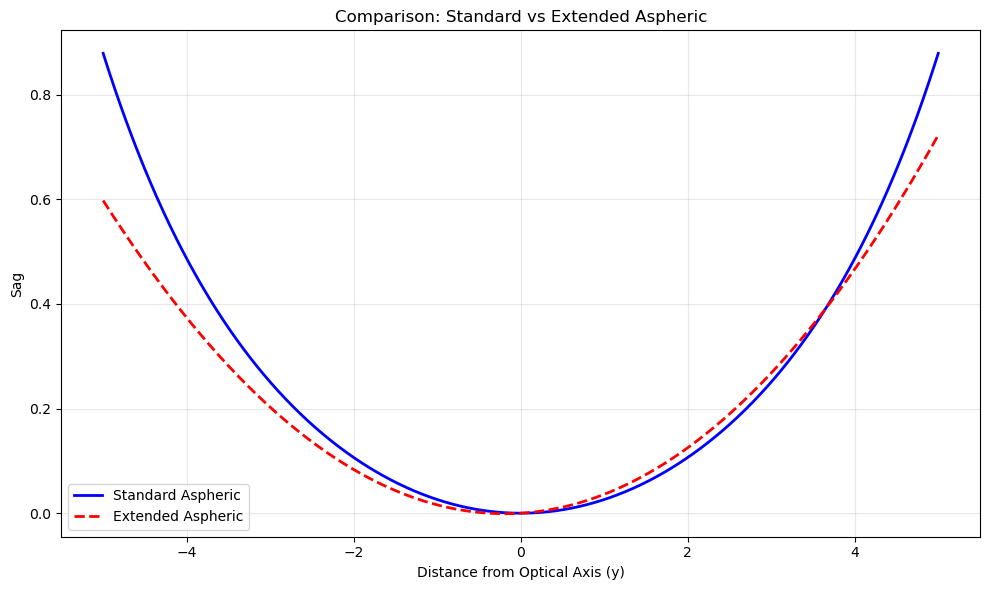

6. Plotting stepped pyramid ARC structure...


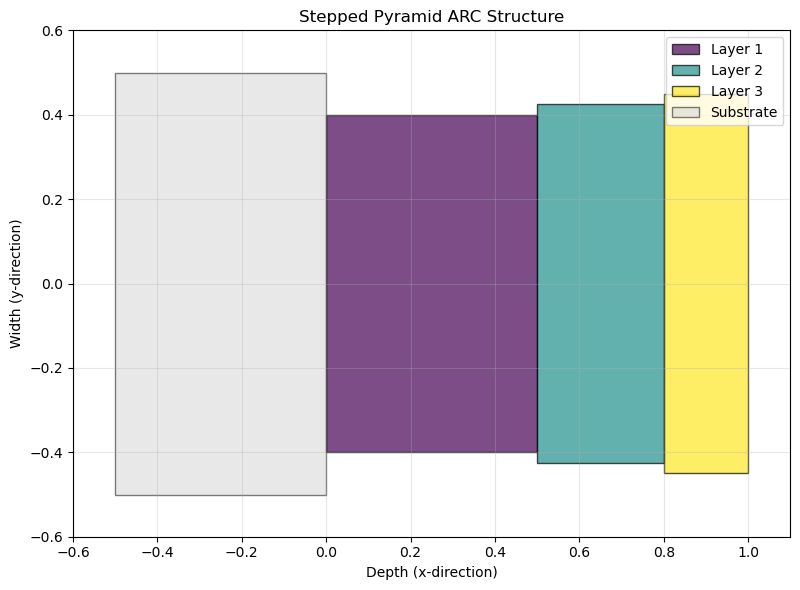

7. Plotting multi-layer AR coating...


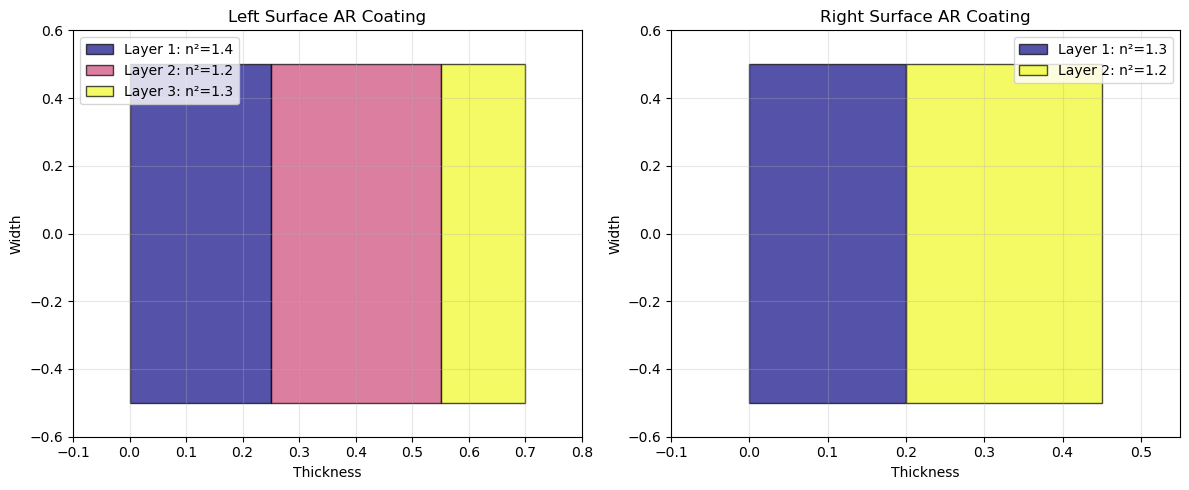


Visualization complete!


In [1]:
#!/usr/bin/env python3
"""
Lens Feature Visualization Script

This script creates various plots to visualize the features and characteristics
of the AsphericLens class from components_2D_eps.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import math

class LensVisualizer:
    """Class to visualize different features of the AsphericLens"""
    
    def __init__(self):
        self.fig_size = (15, 12)
        self.dpi = 100
        
    def plot_lens_sag_profiles(self, diameter=10, r1=20, r2=-20, c1=0, c2=0, 
                              a1_coeffs=[0, 0, 0], a2_coeffs=[0, 0, 0], lens_type='aspheric'):
        """Plot lens sag profiles for left and right surfaces"""
        
        # Create y array from -diameter/2 to +diameter/2
        y = np.linspace(-diameter/2, diameter/2, 1000)
        
        # Calculate sag for both surfaces
        left_sag = self._calculate_sag(y, r1, c1, a1_coeffs, lens_type)
        right_sag = self._calculate_sag(y, r2, c2, a2_coeffs, lens_type)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Left surface
        ax1.plot(y, left_sag, 'b-', linewidth=2, label=f'Left Surface (R={r1})')
        ax1.set_xlabel('Distance from Optical Axis (y)')
        ax1.set_ylabel('Sag')
        ax1.set_title('Left Surface Sag Profile')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Right surface
        ax2.plot(y, right_sag, 'r-', linewidth=2, label=f'Right Surface (R={r2})')
        ax2.set_xlabel('Distance from Optical Axis (y)')
        ax2.set_ylabel('Sag')
        ax2.set_title('Right Surface Sag Profile')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
    def plot_lens_cross_section(self, diameter=10, r1=20, r2=-20, thick=5, 
                               c1=0, c2=0, a1_coeffs=[0, 0, 0], a2_coeffs=[0, 0, 0],
                               lens_type='aspheric', AR_left=None, AR_right=None):
        """Plot 2D cross-section of the lens"""
        
        y = np.linspace(-diameter/2, diameter/2, 1000)
        
        left_sag = self._calculate_sag(y, r1, c1, a1_coeffs, lens_type)
        right_sag = self._calculate_sag(y, r2, c2, a2_coeffs, lens_type) + thick
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot lens surfaces
        ax.plot(left_sag, y, 'b-', linewidth=3, label='Left Surface')
        ax.plot(right_sag, y, 'r-', linewidth=3, label='Right Surface')
        
        # Fill lens area
        ax.fill_betweenx(y, left_sag, right_sag, alpha=0.3, color='lightblue', label='Lens Material')
        
        # Add AR coatings if specified
        if AR_left is not None:
            ar_left = left_sag - AR_left
            ax.plot(ar_left, y, 'g--', linewidth=2, label=f'AR Left ({AR_left})')
            ax.fill_betweenx(y, ar_left, left_sag, alpha=0.5, color='lightgreen')
            
        if AR_right is not None:
            ar_right = right_sag + AR_right
            ax.plot(ar_right, y, 'g--', linewidth=2, label=f'AR Right ({AR_right})')
            ax.fill_betweenx(y, right_sag, ar_right, alpha=0.5, color='lightgreen')
        
        ax.set_xlabel('Position along Optical Axis (x)')
        ax.set_ylabel('Distance from Optical Axis (y)')
        ax.set_title('Lens Cross-Section')
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
        
    def plot_aspheric_comparison(self, diameter=10, r=20, y_range=None):
        """Compare spherical vs aspheric surfaces with different conic constants"""
        
        if y_range is None:
            y_range = diameter/2
            
        y = np.linspace(-y_range, y_range, 1000)
        
        # Different conic constants
        k_values = [0, -0.5, -1, -2, 0.5]
        k_labels = ['Spherical (k=0)', 'Ellipse (k=-0.5)', 'Parabola (k=-1)', 
                   'Hyperbola (k=-2)', 'Oblate Ellipse (k=0.5)']
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors = ['blue', 'red', 'green', 'orange', 'purple']
        
        for i, (k, label, color) in enumerate(zip(k_values, k_labels, colors)):
            sag = self._calculate_sag(y, r, k, [0, 0, 0], 'aspheric')
            ax.plot(y, sag, color=color, linewidth=2, label=label)
        
        ax.set_xlabel('Distance from Optical Axis (y)')
        ax.set_ylabel('Sag')
        ax.set_title('Comparison of Different Aspheric Surfaces')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
    def plot_higher_order_effects(self, diameter=10, r=20, k=0):
        """Show the effect of higher-order aspheric coefficients"""
        
        y = np.linspace(-diameter/2, diameter/2, 1000)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Base aspheric surface
        base_sag = self._calculate_sag(y, r, k, [0, 0, 0], 'aspheric')
        ax.plot(y, base_sag, 'k-', linewidth=2, label='Base Surface (A2=A3=A4=0)')
        
        # Different higher-order coefficients
        coeffs_list = [
            [0.001, 0, 0],     # A2 only
            [0, 0.0001, 0],    # A3 only
            [0, 0, 0.00001],   # A4 only
            [0.001, 0.0001, 0.00001]  # All coefficients
        ]
        
        labels = ['A2=0.001', 'A3=0.0001', 'A4=0.00001', 'All coefficients']
        colors = ['red', 'blue', 'green', 'orange']
        
        for coeffs, label, color in zip(coeffs_list, labels, colors):
            sag = self._calculate_sag(y, r, k, coeffs, 'aspheric')
            ax.plot(y, sag, color=color, linewidth=2, linestyle='--', label=label)
        
        ax.set_xlabel('Distance from Optical Axis (y)')
        ax.set_ylabel('Sag')
        ax.set_title('Effect of Higher-Order Aspheric Coefficients')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
    def plot_stepped_pyramid_arc(self, nlayers=3, pitch=1.0, depth_arr=[0.5, 0.3, 0.2], 
                                kerf_arr=[0.2, 0.15, 0.1]):
        """Visualize stepped pyramid ARC structure"""
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Calculate cumulative depths
        x_positions = [0]
        for i in range(nlayers):
            if i == 0:
                x_positions.append(depth_arr[i])
            else:
                x_positions.append(x_positions[-1] + depth_arr[i])
        
        # Draw each layer
        colors = plt.cm.viridis(np.linspace(0, 1, nlayers))
        
        for i in range(nlayers):
            width = pitch - kerf_arr[i]
            height = depth_arr[i]
            x_start = x_positions[i]
            y_start = -width/2
            
            rect = Rectangle((x_start, y_start), height, width, 
                           facecolor=colors[i], edgecolor='black', alpha=0.7,
                           label=f'Layer {i+1}')
            ax.add_patch(rect)
        
        # Add substrate
        substrate = Rectangle((-0.5, -pitch/2), 0.5, pitch, 
                            facecolor='lightgray', edgecolor='black', 
                            alpha=0.5, label='Substrate')
        ax.add_patch(substrate)
        
        ax.set_xlim(-0.6, x_positions[-1] + 0.1)
        ax.set_ylim(-pitch/2 - 0.1, pitch/2 + 0.1)
        ax.set_xlabel('Depth (x-direction)')
        ax.set_ylabel('Width (y-direction)')
        ax.set_title('Stepped Pyramid ARC Structure')
        ax.legend()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def plot_multi_layer_ar_coating(self, left_layers=[0.25, 0.3, 0.15], 
                                   left_materials=[1.4, 1.2, 1.3],
                                   right_layers=[0.2, 0.25], 
                                   right_materials=[1.3, 1.2]):
        """Visualize multi-layer AR coating structure"""
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Left surface AR coating
        x_pos = 0
        colors1 = plt.cm.plasma(np.linspace(0, 1, len(left_layers)))
        
        for i, (thickness, material, color) in enumerate(zip(left_layers, left_materials, colors1)):
            rect = Rectangle((x_pos, -0.5), thickness, 1, 
                           facecolor=color, edgecolor='black', alpha=0.7,
                           label=f'Layer {i+1}: n²={material:.1f}')
            ax1.add_patch(rect)
            x_pos += thickness
        
        ax1.set_xlim(-0.1, sum(left_layers) + 0.1)
        ax1.set_ylim(-0.6, 0.6)
        ax1.set_xlabel('Thickness')
        ax1.set_ylabel('Width')
        ax1.set_title('Left Surface AR Coating')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Right surface AR coating
        x_pos = 0
        colors2 = plt.cm.plasma(np.linspace(0, 1, len(right_layers)))
        
        for i, (thickness, material, color) in enumerate(zip(right_layers, right_materials, colors2)):
            rect = Rectangle((x_pos, -0.5), thickness, 1, 
                           facecolor=color, edgecolor='black', alpha=0.7,
                           label=f'Layer {i+1}: n²={material:.1f}')
            ax2.add_patch(rect)
            x_pos += thickness
        
        ax2.set_xlim(-0.1, sum(right_layers) + 0.1)
        ax2.set_ylim(-0.6, 0.6)
        ax2.set_xlabel('Thickness')
        ax2.set_ylabel('Width')
        ax2.set_title('Right Surface AR Coating')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def plot_lens_types_comparison(self, diameter=10, r=20, c=0):
        """Compare aspheric vs extended aspheric lens types"""
        
        y = np.linspace(-diameter/2, diameter/2, 1000)
        
        # Standard aspheric coefficients [A2, A3, A4]
        aspheric_coeffs = [0.001, 0.0001, 0.00001]
        
        # Extended aspheric coefficients [A1, A2, A3]
        extended_coeffs = [0.01, 0.001, 0.0001]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Standard aspheric
        sag_aspheric = self._calculate_sag(y, r, c, aspheric_coeffs, 'aspheric')
        ax.plot(y, sag_aspheric, 'b-', linewidth=2, label='Standard Aspheric')
        
        # Extended aspheric
        sag_extended = self._calculate_sag(y, r, c, extended_coeffs, 'extended_aspheric')
        ax.plot(y, sag_extended, 'r--', linewidth=2, label='Extended Aspheric')
        
        ax.set_xlabel('Distance from Optical Axis (y)')
        ax.set_ylabel('Sag')
        ax.set_title('Comparison: Standard vs Extended Aspheric')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
    def _calculate_sag(self, y, r, k, higher_order_coeffs, lens_type):
        """Helper method to calculate sag using lens equations"""
        
        if r == np.inf:
            return np.zeros_like(y)
        
        if lens_type == 'aspheric':
            A2, A3, A4 = higher_order_coeffs
            sag = (y**2/r) / (1 + np.sqrt(1 - (1 + k)*y**2/r**2)) + A2 * y**2 + A3 * y**4 + A4 * y**6
        elif lens_type == 'extended_aspheric':
            A1, A2, A3 = higher_order_coeffs
            sag = (y**2/r) / (1 + np.sqrt(1 - (1 + k)*y**2/r**2)) + A1 * y + A2 * y**2 + A3 * y**3
        else:
            raise ValueError("Invalid lens type")
            
        return sag
        
    def create_comprehensive_plot(self):
        """Create a comprehensive plot showing multiple lens features"""
        
        fig = plt.figure(figsize=(16, 12))
        
        # Create subplots
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
        
        # 1. Lens cross-section
        ax1 = fig.add_subplot(gs[0, :2])
        self._plot_lens_cross_section_subplot(ax1)
        
        # 2. Sag profiles
        ax2 = fig.add_subplot(gs[0, 2])
        self._plot_sag_profiles_subplot(ax2)
        
        # 3. Aspheric comparison
        ax3 = fig.add_subplot(gs[1, 0])
        self._plot_aspheric_comparison_subplot(ax3)
        
        # 4. Higher-order effects
        ax4 = fig.add_subplot(gs[1, 1])
        self._plot_higher_order_subplot(ax4)
        
        # 5. Stepped pyramid ARC
        ax5 = fig.add_subplot(gs[1, 2])
        self._plot_stepped_pyramid_subplot(ax5)
        
        # 6. AR coating layers
        ax6 = fig.add_subplot(gs[2, :])
        self._plot_ar_layers_subplot(ax6)
        
        plt.suptitle('AsphericLens Class Features Overview', fontsize=16, fontweight='bold')
        plt.show()
        
    def _plot_lens_cross_section_subplot(self, ax):
        """Helper for comprehensive plot"""
        diameter, r1, r2, thick = 10, 20, -20, 5
        y = np.linspace(-diameter/2, diameter/2, 200)
        left_sag = self._calculate_sag(y, r1, 0, [0, 0, 0], 'aspheric')
        right_sag = self._calculate_sag(y, r2, 0, [0, 0, 0], 'aspheric') + thick
        
        ax.plot(left_sag, y, 'b-', linewidth=2, label='Left')
        ax.plot(right_sag, y, 'r-', linewidth=2, label='Right')
        ax.fill_betweenx(y, left_sag, right_sag, alpha=0.3, color='lightblue')
        ax.set_title('Lens Cross-Section')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def _plot_sag_profiles_subplot(self, ax):
        """Helper for comprehensive plot"""
        y = np.linspace(-5, 5, 100)
        sag = self._calculate_sag(y, 20, 0, [0, 0, 0], 'aspheric')
        ax.plot(y, sag, 'g-', linewidth=2)
        ax.set_title('Sag Profile')
        ax.set_xlabel('y')
        ax.set_ylabel('Sag')
        ax.grid(True, alpha=0.3)
        
    def _plot_aspheric_comparison_subplot(self, ax):
        """Helper for comprehensive plot"""
        y = np.linspace(-3, 3, 100)
        for k, color in zip([0, -1], ['blue', 'red']):
            sag = self._calculate_sag(y, 20, k, [0, 0, 0], 'aspheric')
            ax.plot(y, sag, color=color, linewidth=2, label=f'k={k}')
        ax.set_title('Aspheric Types')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def _plot_higher_order_subplot(self, ax):
        """Helper for comprehensive plot"""
        y = np.linspace(-3, 3, 100)
        sag1 = self._calculate_sag(y, 20, 0, [0, 0, 0], 'aspheric')
        sag2 = self._calculate_sag(y, 20, 0, [0.001, 0, 0], 'aspheric')
        ax.plot(y, sag1, 'k-', linewidth=2, label='Base')
        ax.plot(y, sag2, 'r--', linewidth=2, label='With A2')
        ax.set_title('Higher-Order Effects')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def _plot_stepped_pyramid_subplot(self, ax):
        """Helper for comprehensive plot"""
        # Simple stepped pyramid visualization
        layers = [0.5, 0.3, 0.2]
        x_pos = 0
        for i, layer in enumerate(layers):
            rect = Rectangle((x_pos, -0.5), layer, 1, 
                           facecolor=plt.cm.viridis(i/len(layers)), alpha=0.7)
            ax.add_patch(rect)
            x_pos += layer
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.6, 0.6)
        ax.set_title('Stepped Pyramid ARC')
        ax.set_aspect('equal')
        
    def _plot_ar_layers_subplot(self, ax):
        """Helper for comprehensive plot"""
        layers = [0.25, 0.3, 0.15]
        materials = [1.4, 1.2, 1.3]
        x_pos = 0
        for i, (layer, mat) in enumerate(zip(layers, materials)):
            rect = Rectangle((x_pos, -0.5), layer, 1, 
                           facecolor=plt.cm.plasma(i/len(layers)), alpha=0.7,
                           label=f'n²={mat}')
            ax.add_patch(rect)
            x_pos += layer
        ax.set_xlim(-0.1, 0.8)
        ax.set_ylim(-0.6, 0.6)
        ax.set_title('Multi-layer AR Coating')
        ax.legend()


def main():
    """Main function to demonstrate lens visualization features"""
    
    visualizer = LensVisualizer()
    
    print("AsphericLens Feature Visualization")
    print("=" * 40)
    
    # Create comprehensive overview
    print("Creating comprehensive lens features overview...")
    visualizer.create_comprehensive_plot()
    
    # Individual feature plots
    print("\nCreating individual feature plots...")
    
    # 1. Lens sag profiles
    print("1. Plotting lens sag profiles...")
    visualizer.plot_lens_sag_profiles(diameter=10, r1=20, r2=-20)
    
    # 2. Lens cross-section
    print("2. Plotting lens cross-section...")
    visualizer.plot_lens_cross_section(diameter=10, r1=20, r2=-20, thick=5, 
                                      AR_left=0.5, AR_right=0.3)
    
    # 3. Aspheric comparison
    print("3. Plotting aspheric surface comparison...")
    visualizer.plot_aspheric_comparison(diameter=10, r=20)
    
    # 4. Higher-order effects
    print("4. Plotting higher-order coefficient effects...")
    visualizer.plot_higher_order_effects(diameter=10, r=20)
    
    # 5. Lens types comparison
    print("5. Plotting lens types comparison...")
    visualizer.plot_lens_types_comparison(diameter=10, r=20)
    
    # 6. Stepped pyramid ARC
    print("6. Plotting stepped pyramid ARC structure...")
    visualizer.plot_stepped_pyramid_arc(nlayers=3, pitch=1.0, 
                                       depth_arr=[0.5, 0.3, 0.2], 
                                       kerf_arr=[0.2, 0.15, 0.1])
    
    # 7. Multi-layer AR coating
    print("7. Plotting multi-layer AR coating...")
    visualizer.plot_multi_layer_ar_coating()
    
    print("\nVisualization complete!")


if __name__ == "__main__":
    main()